In [105]:
import pandas as pd
import csv
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.stats import pearsonr, spearmanr
from scipy.stats import mannwhitneyu

In [106]:
filename = 'data/final_enr_imr90.csv'
columns = ['diseaseId', '#snp', '#border_snp', 'pval_tad', 'pval_border', 'pval_outside', 'is_cancer', 'window_size', 'filter']
df = pd.read_csv(filename, usecols=columns)
print(df.head)

<bound method NDFrame.head of              diseaseId  #snp  #border_snp  pval_tad  pval_border  \
0          EFO_0000094    22           13  0.000000     0.000000   
1          EFO_0000095   130           72  0.000000     0.000000   
2          EFO_0000096    13            6  0.000000     0.000000   
3          EFO_0000174     7            3  0.000000     0.000000   
4          EFO_0000178    37           16  0.000000     0.000000   
...                ...   ...          ...       ...          ...   
71741    Orphanet_1945    11            0       NaN          NaN   
71742  Orphanet_391311    15            5  0.950432     0.172214   
71743     Orphanet_654     7            3  0.969582     0.088117   
71744   Orphanet_93957     3            0       NaN          NaN   
71745   Orphanet_98974     7            2  0.730591     0.294210   

       pval_outside  is_cancer  window_size     filter  
0          1.000000      False            0   nofilter  
1          1.000000      False         

In [107]:
df.shape

(71746, 9)

In [108]:
df = df[(df['#snp'] != 1) & (df['#border_snp'] != 1)]
df.shape

(52196, 9)

In [109]:
df = df[df['#border_snp'] != 0]
df.shape

(43950, 9)

In [110]:
columns = ['diseaseId', 'z_score', 'pvalue', 'mean_centrality']
combined = pd.read_csv("data/mean_centrality_networkit.csv", sep='\t', usecols=columns)
print(combined.head())

       diseaseId    z_score    pvalue  mean_centrality
0    EFO_0004193   4.690213  0.000031         0.000984
1    EFO_0000707   3.968751  0.001300         0.002581
2    EFO_0010176   5.038859  0.004000         0.002093
3    EFO_0000389  15.667010  0.000000         0.001396
4  MONDO_0005575   0.216129  0.002900         0.000247


In [111]:
full_df = pd.merge(df, combined, on="diseaseId", how='inner', indicator=True)
full_df["log_pval_border"] = -np.log10(full_df["pval_border"])
full_df = full_df.replace([np.inf, -np.inf], np.nan)
full_df = full_df.dropna(subset=['z_score', 'pval_border', 'mean_centrality', 'log_pval_border'])

/Users/aliaarman/TADandPPI/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
def get_scatterplot(df1, filter, df2, type, y_col, window=None):
    if window is not None:
        df1 = df1[df1['window_size'] == window]
    
    df1 = df1[df1['filter'] == filter]
    combined_data = pd.merge(df1, df2, on='diseaseId', how='inner', indicator=True)
    
    df1_excluded = df1[~df1['diseaseId'].isin(combined_data['diseaseId'])]
    df2_excluded = df2[~df2['diseaseId'].isin(combined_data['diseaseId'])]

    print("\nRows from PPI Network dataset that were NOT included:")
    print(df2_excluded, f'length: {len(df2_excluded)}')
    
    print(f'number of null points: {combined_data.isnull().sum()}') 
    print(combined_data[['pval_border', y_col]].describe())
    combined_data = combined_data.dropna(subset=['pval_border', y_col])
    
    sns.scatterplot(data=combined_data, x='pval_border', y=y_col, hue='is_cancer', palette={True: 'red', False: 'blue'}, alpha=0.5, s=30)
    plt.axvline(x=0.05, color='black', linestyle='dashed', label='P = 0.05')
    #plt.axhline(y=2.0, color='black', linestyle='dashed', label='Z = 2')
    plt.xscale('log')
    plt.gca().invert_xaxis()
    plt.xlabel(f'TAD Border -log10(P-value). window: {window}, filter: {filter}')
    plt.ylabel('Z Score')
    cancer_data = combined_data[combined_data['is_cancer'] == True]
    noncancer_data = combined_data[combined_data['is_cancer'] == False]
    legend_items = [
        patches.Patch(color='red', label=f'True {len(cancer_data)}'), 
        patches.Patch(color='blue', label=f'False {len(noncancer_data)}')
        ]
    plt.legend(title='Is Cancer', handles=legend_items, loc='upper right', framealpha = 0.5)
    plt.title(f'Comparison of PPI Z score to TAD border P value. {len(combined_data)} points')

    
    if len(combined_data) >= 2:
        if len(cancer_data) >= 2 and len(noncancer_data) >= 2:
            stats = {
                "Combined Pearson": pearsonr(combined_data["pval_border"], combined_data[y_col]),
                "Combined Spearman": spearmanr(combined_data["pval_border"], combined_data[y_col]),
                "Cancer Pearson": pearsonr(cancer_data["pval_border"], cancer_data[y_col]), 
                "Cancer Spearman": spearmanr(cancer_data["pval_border"], cancer_data[y_col]),
                "Noncancer Pearson": pearsonr(noncancer_data["pval_border"], noncancer_data[y_col]), 
                "Noncancer Spearman": spearmanr(noncancer_data["pval_border"], noncancer_data[y_col])
            }
        else:
            stats = {
                "Combined Pearson": pearsonr(combined_data["pval_border"], combined_data[y_col]),
                "Combined Spearman": spearmanr(combined_data["pval_border"], combined_data[y_col])
            }
            
        table_data = [
            ["Metric", "r", "p"]
        ]
        
        for key, value in stats.items():
            table_data.append([key, f"{value[0]:.5f}", f"{value[1]:.3e}"])

        table = plt.table(cellText=table_data, colLabels=None, cellLoc='center', loc='bottom', bbox=[0, -0.5, 1, 0.3])
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1.2)
        
        

    #plt.savefig(f'results_graphs_biogrid/{type}/comparison_{type}_{window}_{filter}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_boxplot(zscore_df, path=None):
    filters = ['exonic', 'intronic', 'intergenic', 'nonexonic']
    filter_labels = [f.capitalize() for f in filters]
    palette = ['brown', 'indianred', 'salmon', 'mistyrose']

    plt.figure(figsize=(6, 3))

    ax = sns.boxplot(
        data=zscore_df,
        x='Region',
        y='z_score',
        hue='Filter',
        palette=palette,
        linewidth=2.5,
        fliersize=3,  # Size of outlier dots
        boxprops=dict(edgecolor='0.2'),
        medianprops=dict(color='0.2', linewidth=2.5),
        whiskerprops=dict(color='0.2', linewidth=2.5),
        capprops=dict(color='0.2', linewidth=2.5)
    )

    # Style tweaks (same as your original barplot)
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(2.5)
        ax.spines[axis].set_color('0.2')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    ax.axhline(0, linewidth=2, color='0.2')

    plt.xticks(size=14, rotation=35, rotation_mode='anchor', ha='center', weight='bold', color='0.2')
    plt.yticks(size=14, weight='bold', color='0.2')
    ax.tick_params(width=2.5, color='0.2', direction='inout', length=10)
    plt.xlabel('')
    plt.ylabel('Z-scores', size=14, weight='bold', color='0.2')

    plt.legend(loc=10, bbox_to_anchor=(0.5, -0.33), ncol=2, frameon=False, fontsize=16, labelcolor='0.2', prop={'weight': 'bold'})

    if path:
        plt.savefig(path, bbox_inches='tight', dpi=300)
    plt.tight_layout()
    plt.show()


In [112]:
cancer_vals = full_df[full_df["is_cancer"] == True]["mean_centrality"]
noncancer_vals = full_df[full_df["is_cancer"] == False]["mean_centrality"]

stat, p = mannwhitneyu(cancer_vals, noncancer_vals, alternative='two-sided')
print(f"Mann–Whitney U test p-value: {p:.3e}, U: {stat:.3e}")


Mann–Whitney U test p-value: 7.803e-48, U: 1.449e+07


In [113]:
filtered = full_df[full_df['filter'] == 'nonexonic'].dropna(subset=["mean_centrality", "log_pval_border"])

rho, pval = spearmanr(filtered["mean_centrality"], filtered["log_pval_border"])
print(f"Spearman correlation: rho={rho:.3f}, p={pval:.3e}")

Spearman correlation: rho=0.168, p=1.566e-21


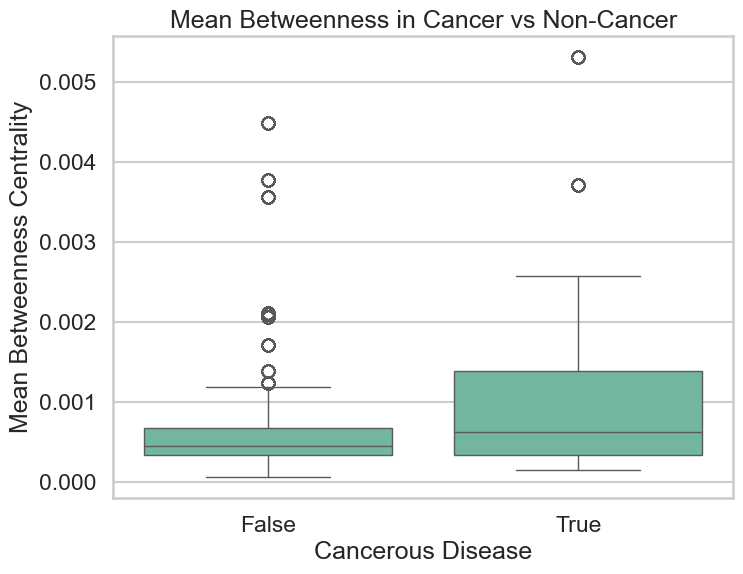

In [115]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=full_df, x="is_cancer", y="mean_centrality")
plt.xlabel("Cancerous Disease")
plt.ylabel("Mean Betweenness Centrality")
plt.title("Mean Betweenness in Cancer vs Non-Cancer")
plt.show()


In [146]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(full_df[["log_pval_border", "mean_centrality", "z_score"]])


In [147]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

full_df['cluster'] = clusters


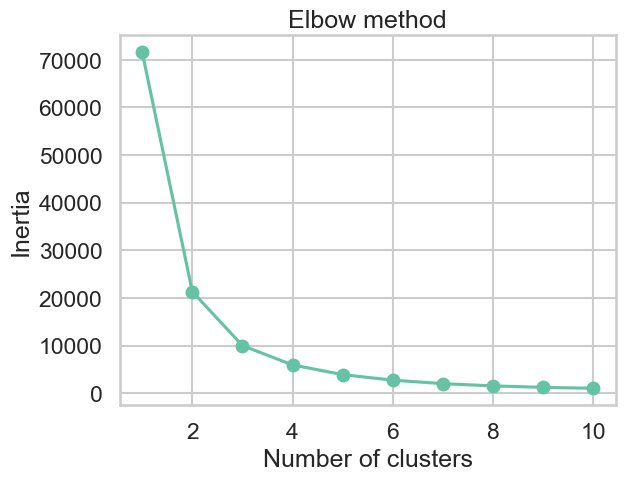

In [148]:
data = list(zip(full_df["log_pval_border"], full_df["mean_centrality"]))
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show() 

In [149]:
full_df

,diseaseId,#snp,#border_snp,pval_tad,pval_border,pval_outside,is_cancer,window_size,filter,z_score,pvalue,mean_centrality,_merge,log_pval_border,cluster
80,EFO_0000095,130,52,1.000000,4.149095e-04,1.000000,False,3,nofilter,7.770321,3.250000e-06,0.001155,both,3.382047,0
81,EFO_0000195,261,101,1.000000,3.054780e-06,1.000000,False,3,nofilter,3.113403,4.440000e-16,0.000351,both,5.515020,0
82,EFO_0000274,111,40,1.000000,1.636998e-02,1.000000,False,3,nofilter,7.647706,4.370000e-10,0.000548,both,1.785952,0
83,EFO_0000275,373,161,1.000000,6.255159e-14,1.000000,False,3,nofilter,4.578832,3.000000e-04,0.000695,both,13.203762,0
85,EFO_0000319,331,148,1.000000,1.942890e-14,1.000000,False,3,nofilter,4.950163,1.890000e-06,0.000605,both,13.711552,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14838,EFO_1001976,14,3,0.866507,4.377952e-01,1.000000,False,20,nonexonic,4.489599,1.300000e-04,0.000566,both,0.358729,0
14839,EFO_1002011,145,36,0.998767,1.296032e-01,1.000000,False,20,nonexonic,9.148134,7.930000e-08,0.000449,both,0.887384,0
14840,EFO_1002013,127,58,1.000000,3.414841e-11,1.000000,False,20,nonexonic,3.055805,8.850000e-05,0.000203,both,10.466630,0
14841,EFO_1002019,30,9,1.000000,1.601990e-01,0.366693,False,20,nonexonic,23.827694,6.080000e-13,0.001109,both,0.795340,0


In [150]:
pd.crosstab(full_df['cluster'], full_df['is_cancer'])


is_cancer,False,True
cluster,,
0,12232,1688
1,200,247


<Axes: xlabel='cluster', ylabel='z_score'>

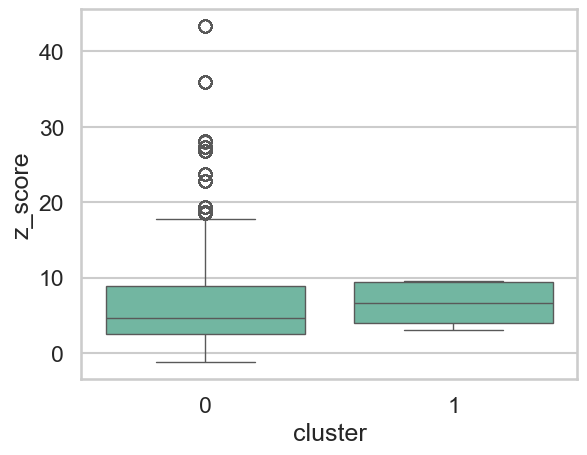

In [151]:
sns.boxplot(data=full_df, x='cluster', y='z_score')

<Axes: xlabel='cluster', ylabel='mean_centrality'>

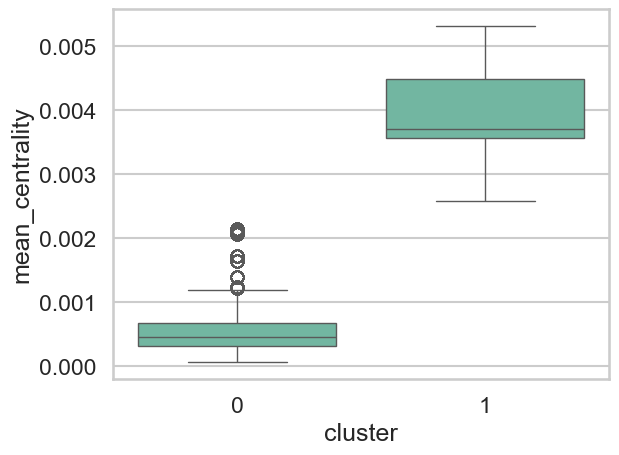

In [162]:
sns.boxplot(data=full_df, x='cluster', y='mean_centrality')

<Axes: xlabel='cluster', ylabel='z_score'>

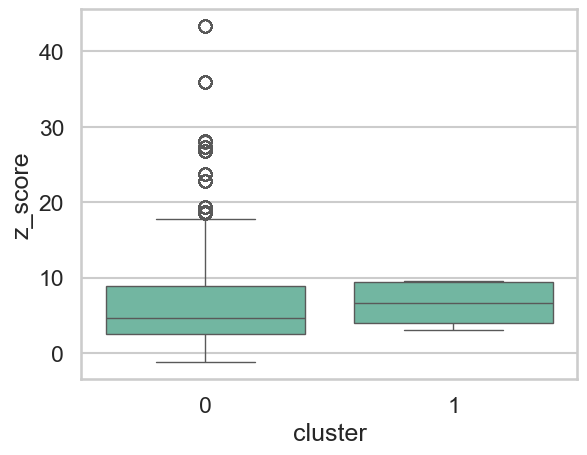

In [163]:
sns.boxplot(data=full_df, x='cluster', y='z_score')

In [154]:
cluster1_vals = full_df[full_df["cluster"] == 1]["mean_centrality"]
cluster0_vals = full_df[full_df["cluster"] == 0]["mean_centrality"]

stat, p = mannwhitneyu(cancer_vals, noncancer_vals, alternative='two-sided')
print(f"Mann–Whitney U test p-value: {p:.3e}, U: {stat:.3e}")

Mann–Whitney U test p-value: 7.803e-48, U: 1.449e+07


In [155]:
from scipy.stats import chi2_contingency, fisher_exact

contingency_table = pd.DataFrame({
    'Cluster 0': [full_df[(full_df['is_cancer'] == True) & (full_df['cluster'] == 0)].shape[0], full_df[(full_df['is_cancer'] == False) & (full_df['cluster'] == 0)].shape[0]],
    'Cluster 1': [full_df[(full_df['is_cancer'] == True) & (full_df['cluster'] == 1)].shape[0], full_df[(full_df['is_cancer'] == False) & (full_df['cluster'] == 1)].shape[0]]
}, index=['Cancer', 'Noncancer'])

In [156]:
contingency_table

,Cluster 0,Cluster 1
Cancer,1688,247
Noncancer,12232,200


In [157]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2}")
print(f"P-value: {p}")

Chi-square statistic: 687.6041840684939
P-value: 1.4835085156697234e-151


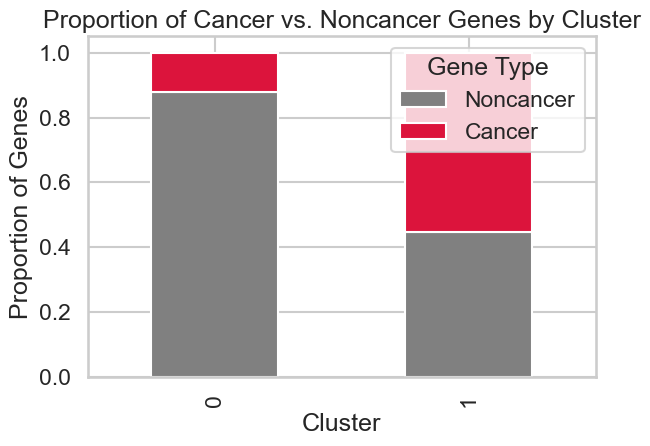

In [158]:
full_df['is_cancer'] = full_df['is_cancer'].astype(bool)

cluster_cancer_counts = full_df.groupby(['cluster', 'is_cancer']).size().unstack(fill_value=0)
cluster_cancer_props = cluster_cancer_counts.div(cluster_cancer_counts.sum(axis=1), axis=0)

cluster_cancer_props.plot(kind='bar', stacked=True, color=['gray', 'crimson'])
plt.ylabel('Proportion of Genes')
plt.xlabel('Cluster')
plt.title('Proportion of Cancer vs. Noncancer Genes by Cluster')
plt.legend(['Noncancer', 'Cancer'], title='Gene Type')
plt.tight_layout()
plt.show()


/var/folders/4g/n465f8j14bq_nt2x3wjkt8pw0000gn/T/ipykernel_80129/4258878049.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x='cluster', y='log_pval_border', ax=axes[1], palette='Set2')
/var/folders/4g/n465f8j14bq_nt2x3wjkt8pw0000gn/T/ipykernel_80129/4258878049.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x='cluster', y='mean_centrality', ax=axes[2], palette='Set2')


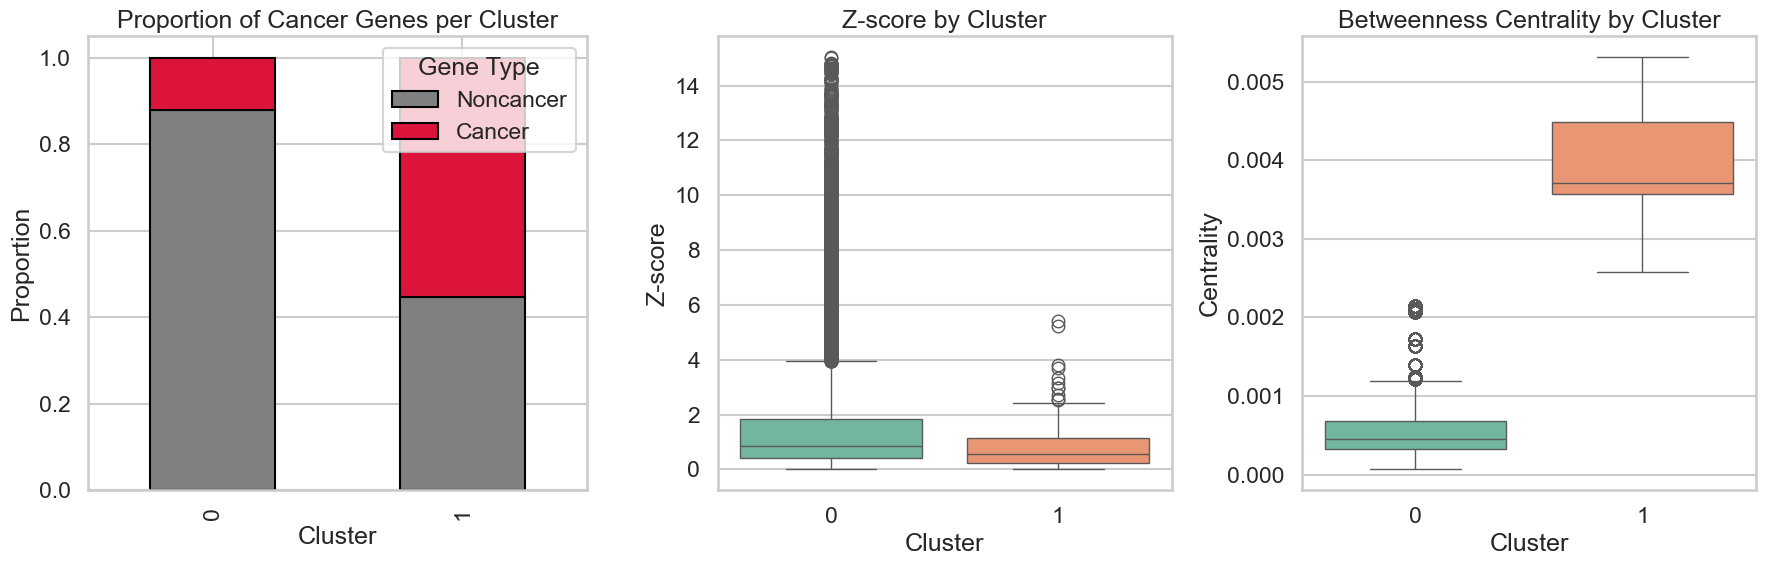

In [160]:
# Optional: Use your custom style
sns.set(style="whitegrid", palette="Set2", context="talk")

# --- Replace with your actual DataFrame ---
# Assumes `full_df` has the following columns:
# - 'cluster' (0 or 1)
# - 'is_cancer' (True/False)
# - 'zscore'
# - 'betweenness_centrality'

# Ensure proper data types
full_df['is_cancer'] = full_df['is_cancer'].astype(bool)

# Create contingency counts
cluster_cancer_counts = full_df.groupby(['cluster', 'is_cancer']).size().unstack(fill_value=0)
cluster_cancer_props = cluster_cancer_counts.div(cluster_cancer_counts.sum(axis=1), axis=0)

# Set up the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1.1, 1, 1]})

# --- Plot 1: Stacked bar plot for cancer proportions ---
cluster_cancer_props.plot(kind='bar', stacked=True, ax=axes[0], color=['gray', 'crimson'], edgecolor='black')
axes[0].set_title('Proportion of Cancer Genes per Cluster')
axes[0].set_ylabel('Proportion')
axes[0].set_xlabel('Cluster')
axes[0].legend(['Noncancer', 'Cancer'], title='Gene Type')
axes[0].set_ylim(0, 1.05)

# --- Plot 2: Boxplot for z-scores ---
sns.boxplot(data=full_df, x='cluster', y='log_pval_border', ax=axes[1], palette='Set2')
axes[1].set_title('Z-score by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Z-score')

# --- Plot 3: Boxplot for centrality ---
sns.boxplot(data=full_df, x='cluster', y='mean_centrality', ax=axes[2], palette='Set2')
axes[2].set_title('Betweenness Centrality by Cluster')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Centrality')

# --- Final touches ---
plt.tight_layout()
#plt.savefig("cluster_summary_figure.png", dpi=300)
plt.show()


In [ ]:
def get_region_counts(df):
    region_11 = (df['z_score'] >= 2) & (df['pval_border'] < 0.05)
    region_01 = (df['z_score'] < 2) & (df['pval_border'] < 0.05)
    region_10 = (df['z_score'] >= 2) & (df['pval_border'] >= 0.05)
    region_00 = (df['z_score'] < 2) & (df['pval_border'] >= 0.05)

    
    region_11_count = np.sum(region_11)
    region_01_count = np.sum(region_01)
    region_10_count = np.sum(region_10)
    region_00_count = np.sum(region_00)
    
    num = {'11': region_11_count, '01': region_01_count, '10': region_10_count, '00': region_00_count}
    diff = (num['01'] + num['10']) - num['11']
    
    return num

In [ ]:
def shuffle_analysis(df1, df2):
    combined_data = pd.merge(df1, df2, on='diseaseId', how='inner', indicator=True)
    combined_data = combined_data[combined_data['is_cancer'] == False]
    pval_shuffled = np.random.permutation(combined_data['pval_border'].values)
    z_shuffled = np.random.permutation(combined_data['z_score'].values)
    
    shuffled_df = combined_data.copy()
    shuffled_df['pval_border'] = pval_shuffled
    shuffled_df['z_score'] = z_shuffled
    
    num = get_region_counts(shuffled_df)
    
    return num

In [ ]:
combined = pd.concat([df_cancers, df_noncancers])
mask = combined['pvalue'] == 0.0
combined.loc[mask, 'pvalue'] = combined.loc[mask, 'p_empirical']
combined.head

In [ ]:
filters = ['nofilter', 'exonic', 'intronic', 'intergenic', 'nonexonic']
actual_num = {}

for filter in filters:
    df1 = df[df['filter'] == filter]
    combined_data = pd.merge(df1, combined, on='diseaseId', how='inner', indicator=True)
    
    num = get_region_counts(combined_data[combined_data['is_cancer'] == False])
    print(num)
    actual_num[filter] = num



In [ ]:
shuffled_11 = {}
shuffled_01 = {}
shuffled_10 = {}
shuffled_00 = {}
filters = ['nofilter', 'exonic', 'intronic', 'intergenic', 'nonexonic']

for filter in filters:
    shuffled_11[filter] = []
    shuffled_01[filter] = []
    shuffled_10[filter] = []
    shuffled_00[filter] = []
    for i in range(10000):
        df1 = df[df['filter'] == filter]
        num = shuffle_analysis(df1, combined)
        shuffled_11[filter].append(num['11'])
        shuffled_01[filter].append(num['01'])
        shuffled_10[filter].append(num['10'])
        shuffled_00[filter].append(num['00'])

In [ ]:
len(shuffled_01['exonic'])

In [ ]:
shuffled_data = {}
for filter in filters:
    shuffled_data[filter] = {}
    shuffled_data[filter]['00'] = shuffled_00[filter] 
    shuffled_data[filter]['10'] = shuffled_10[filter]
    shuffled_data[filter]['01'] = shuffled_01[filter] 
    shuffled_data[filter]['11'] = shuffled_11[filter]

In [ ]:
def get_zscores(shuffled_data, num):
    zscore_regions = {}
    for filter in shuffled_data.keys():
        zscore_regions[filter] = {}
        for region in shuffled_data[filter].keys():
            mean = np.mean(shuffled_data[filter][region])
            std = np.std(shuffled_data[filter][region])
            print(mean, std)
            if std == 0:
                zscore_regions[filter][region] = np.nan
            else:
                zscore_regions[filter][region] = (num[filter][region] - mean) / std
    return zscore_regions

In [ ]:
zscore_regions = get_zscores(shuffled_data, actual_num)
zscore_regions

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

def plot_regions_cleaned(shuffled_data, actual_num, z_scores, path):
    sns.set(style="whitegrid")
    filters = ['nofilter', 'exonic', 'intronic', 'intergenic', 'nonexonic']
    regions = {
        '00': 'Z−, P−',
        '01': 'Z−, P+',
        '10': 'Z+, P−',
        '11': 'Z+, P+'
    }

    for filter in filters:
        fig = plt.figure(figsize=(12, 10))
        spec = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.3)
        fig.suptitle(f"SNP-TAD Enrichment Distribution — Filter: {filter.capitalize()}", fontsize=18, fontweight='bold')

        for i, (region, label) in enumerate(regions.items()):
            ax = fig.add_subplot(spec[i])
            sns.histplot(shuffled_data[filter][region], bins=30, kde=True, ax=ax,
                         color='#4878CF', edgecolor='black', alpha=0.7)

            ax.axvline(actual_num[filter][region], color="#D65F5F", linestyle="--", linewidth=2,
                       label=f"Actual Count: {actual_num[filter][region]}")

            ax.set_title(f"Region {region} ({label}) — Z: {z_scores[filter][region]:.2f}", fontsize=12)
            ax.set_xlabel("Edge Count", fontsize=11)
            ax.set_ylabel("Frequency", fontsize=11)
            ax.legend(loc='upper left', frameon=True)

        plt.savefig(f"{path}/{filter}_cleaned.png", dpi=300, bbox_inches='tight')
        plt.close()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_regions_matrix(shuffled_data, actual_num, z_scores, path,
                         bins=30, kde=True, palette="#4878CF"):

    sns.set(style="whitegrid")
    filters = ['exonic', 'intronic', 'intergenic', 'nonexonic']
    filter_labels = [f.capitalize() for f in filters]

    regions = ['00', '01', '10', '11']
    region_labels = ['Z−,P−', 'Z−,P+', 'Z+,P−', 'Z+,P+']

    # Make one big figure
    n_rows, n_cols = len(filters), len(regions)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols*3.2, n_rows*2.6),
                             sharex=False, sharey=False)

    for r, flt in enumerate(filters):
        for c, reg in enumerate(regions):
            ax = axes[r, c]
            sns.histplot(shuffled_data[flt][reg],
                         bins=bins, kde=kde, ax=ax,
                         color=palette, edgecolor='black', alpha=0.7)

            # Vertical line for actual edge‑count
            ax.axvline(actual_num[flt][reg],
                       color="#D65F5F", linestyle="--", linewidth=1.8)

            # Titles and labels
            if r == 0:      # top row → column headers
                ax.set_title(region_labels[c], fontsize=11, pad=6)
            if c == 0:      # first col → row labels
                ax.set_ylabel(f"{filter_labels[r]}\nFrequency", fontsize=10)
            else:
                ax.set_ylabel("")

            ax.set_xlabel("Edge count", fontsize=9)
            # Embed z‑score inside the axes (top‑left corner)
            ax.text(0.02, 0.92, f"z={z_scores[flt][reg]:.2f}",
                    transform=ax.transAxes, fontsize=8,
                    ha="left", va="top",
                    bbox=dict(boxstyle="round,pad=0.15",
                              facecolor="white", alpha=0.6, lw=0))

    fig.suptitle("SNP-TAD Enrichment - Shuffled vs. Actual",
                 fontsize=16, weight='bold', y=1.02)
    plt.tight_layout()
    fig.savefig(f"{path}/shuffled_labels_hist_matrix.png", dpi=300,
                bbox_inches='tight')
    plt.close(fig)


In [ ]:
plot_regions_matrix(shuffled_data, actual_num, zscore_regions, 'results_graphs_biogrid/')

In [ ]:
plot_regions_cleaned(shuffled_data, actual_num, zscore_regions, 'results_graphs/shuffled_regions_cleaned')

In [ ]:
region_labels = {'00': 'Z−,P−', '01': 'Z−,P+', '10': 'Z+,P−', '11': 'Z+,P+'}

In [ ]:
flat_rows = [
    {'Filter': filter_name, 'Region': region_labels[region], 'z_score': z}
    for filter_name, region_dict in zscore_regions.items()
    for region, z in region_dict.items()
]

zscore_df = pd.DataFrame(flat_rows)

In [ ]:
zscore_df = zscore_df[zscore_df['Filter'] != 'nofilter']

In [ ]:
def plot_reg_z_scores(zscore_df, path=None):
    filters = ['exonic', 'intronic', 'intergenic', 'nonexonic']
    filter_labels = [f.capitalize() for f in filters]
    
    palette = ['brown', 'indianred', 'salmon', 'mistyrose']

    plt.figure(figsize=(6,3))
    
    

    ax = sns.barplot(data=zscore_df, x='Region', y='z_score', capsize=0.5, edgecolor ='0.2', lw = 2.5, errwidth=2.5, errcolor='0.2', hue='Filter', palette=palette)
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(2.5)
        ax.spines[axis].set_color('0.2')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    ax.axhline(0, linewidth=2, color='0.2')

    plt.xticks(size = 14, rotation= 35, rotation_mode = 'anchor', ha='center', weight='bold', color='0.2')
    plt.yticks(size = 14, weight='bold', color='0.2')
    plt.xlabel('')
    plt.ylabel('Z-scores', size=14, weight='bold', color='0.2')
    plt.legend(loc = 10, bbox_to_anchor = (0.5, -0.33), ncol = 2, frameon = False, fontsize = 16, labelcolor='0.2', prop={'weight': 'bold'})
    
    
    
    #ax = sns.swarmplot(data=zscores_df, x='Filter', y='z_score', marker='s', s=10)

In [ ]:
plot_reg_z_scores(zscore_df)

### Shuffling Cancer/Noncancer Labels and getting region distributions

In [ ]:
merged_df = pd.merge(df, combined, on='diseaseId', how='inner', indicator=True)
original_num = {}
sums = {}

filters = ['nofilter', 'exonic', 'intronic', 'intergenic', 'nonexonic']

original_num['cancer'] = {}
original_num['noncancer'] = {}

for filter in filters:
    original_num['cancer'][filter] = {}
    original_num['noncancer'][filter] = {}
    sums[filter] = {}
    df_filtered = merged_df[merged_df['filter'] == filter]
    cancers_num = (df_filtered['is_cancer'] == True).sum()
    noncancers_num = (df_filtered['is_cancer'] == False).sum()
    sums[filter]['cancer'] = cancers_num
    sums[filter]['noncancer'] = noncancers_num
    
    df_cancers = df_filtered[df_filtered['is_cancer'] == True]
    df_noncancers = df_filtered[df_filtered['is_cancer'] == False]
    
    cancer_output = get_region_counts(df_cancers)
    noncancer_output = get_region_counts(df_noncancers)
    original_num['cancer'][filter] = cancer_output
    original_num['noncancer'][filter] = noncancer_output

sums, original_num
    
    

In [ ]:
def shuffle_labels(df, sums):
    label_shuffled = np.random.permutation(df['is_cancer'].values)
        
    shuffled_df = df.copy()
    shuffled_df['is_cancer'] = label_shuffled
    assert((shuffled_df['is_cancer'] == True).sum() == sums['cancer'])
    assert((shuffled_df['is_cancer'] == False).sum() == sums['noncancer'])
    
    shuffled_cancer = shuffled_df[shuffled_df['is_cancer'] == True]
    shuffled_noncancer = shuffled_df[shuffled_df['is_cancer'] == False]
        
    cancer, noncancer = get_region_counts(shuffled_cancer), get_region_counts(shuffled_noncancer)
        
    return cancer, noncancer

In [ ]:
shuffled_regions_cancer = {}
shuffled_regions_noncancer = {}
regions = ['00', '01', '10', '11']

for filter in filters:
    shuffled_regions_cancer[filter] = {'00' : [], '01': [], '10': [], '11': []}
    shuffled_regions_noncancer[filter] = {'00' : [], '01': [], '10': [], '11': []}
    
    df_filtered = merged_df[merged_df['filter'] == filter]
    
    for i in range(10000):
        cancer, noncancer = shuffle_labels(df_filtered, sums[filter])
        for region in regions:
            shuffled_regions_cancer[filter][region].append(cancer[region])
            shuffled_regions_noncancer[filter][region].append(noncancer[region])
            

shuffled_regions_cancer, shuffled_regions_noncancer

In [ ]:
len(shuffled_regions_cancer['nofilter']['00'])

In [ ]:
zscore_regions_cancers = get_zscores(shuffled_regions_cancer, original_num['cancer'])
zscore_regions_noncancers = get_zscores(shuffled_regions_noncancer, original_num['noncancer'])

### Plots for Shuffled Labels (Cancer/Noncancer)

In [ ]:
plot_regions_matrix(shuffled_regions_cancer, original_num['cancer'], zscore_regions_cancers, 'results_graphs/shuffled_labels/cancer')

In [ ]:
plot_regions_matrix(shuffled_regions_noncancer, original_num['noncancer'], zscore_regions_noncancers, 'results_graphs/shuffled_labels/noncancer')

### Plotting the z-scores as a function of the window parameter

In [ ]:
# shuffled regions

filters = ['nofilter', 'exonic', 'intronic', 'intergenic', 'nonexonic']
actual_num = {}


for filter in filters:
    df_filter = df[df['filter'] == filter]
    actual_num[filter] = {}
    for i in range(0, 21):
        df_window = df_filter[df_filter['window_size'] == i]
        combined_data = pd.merge(df_window, combined, on='diseaseId', how='inner', indicator=True)
        
        num = get_region_counts(combined_data)
        actual_num[filter][i] = num

actual_num


In [ ]:
shuffled_window_num = {}
filters = ['nofilter', 'exonic', 'intronic', 'intergenic', 'nonexonic']

for filter in filters:
    shuffled_window_num[filter] = {}
    df_filter = df[df['filter'] == filter]
    for i in range(0, 21):
        shuffled_window_num[filter][i] = {'00' : [], '01': [], '10': [], '11': []}
        for j in range(10000):
            num = shuffle_analysis(df_filter, combined)
            shuffled_window_num[filter][i]['11'].append(num['11'])
            shuffled_window_num[filter][i]['00'].append(num['00'])
            shuffled_window_num[filter][i]['10'].append(num['10'])
            shuffled_window_num[filter][i]['01'].append(num['01'])
shuffled_window_num

In [ ]:
shuffled_window_num['exonic'][15]

In [ ]:
def get_zscores_windows(shuffled_data, num):
    zscore_regions = {}
    for window in shuffled_data.keys():
        zscore_regions[window] = {}
        for region in shuffled_data[window].keys():
            mean = np.mean(shuffled_data[window][region])
            std = np.std(shuffled_data[window][region])
            print(mean, std)
            if std == 0:
                zscore_regions[window][region] = np.nan
            else:
                zscore_regions[window][region] = (num[window][region] - mean) / std
    return zscore_regions

In [ ]:
z_scores_windows = {}
for filter in filters:
    z_scores_regions = get_zscores_windows(shuffled_window_num[filter], actual_num[filter])
    z_scores_windows[filter] = z_scores_regions

z_scores_windows

In [ ]:
z_scores_windows['intergenic']

In [ ]:
def plot_regions_windows(shuffled_data, actual_num, z_scores, path):
    filters = ['nofilter', 'exonic', 'intronic', 'intergenic', 'nonexonic']
    regions = ['00', '01', '10', '11']
    
    for filter in filters:
        figure, axes = plt.subplots(2, 2, figsize=(10, 8))
        figure.suptitle(f"Region Counts as a function of Window Sizes", fontsize=16)
        
        axes = axes.flatten()
        
        for i, region in enumerate(regions):
            axes[i].plot(z_scores.keys(), z_scores)
            axes[i].set_title(f"Region {region}, z_score: {z_scores[filter][region]:.2f}")
            axes[i].axvline(actual_num[filter][region], color="red", linestyle="dashed", label=f"Actual Count: {actual_num[filter][region]}")
            axes[i].legend()

        plt.tight_layout()
        plt.savefig(f'{path}/{filter}.png', dpi=300, bbox_inches='tight')
        plt.show()

### Scatterplots

In [ ]:
filters = ['nofilter', 'exonic', 'intronic', 'intergenic', 'nonexonic']
for i in filters:
    get_scatterplot(df, i, combined, 'combined')

In [ ]:
def get_network_scatterplot(df1, type):
    sns.scatterplot(data=df1, x='pvalue', y='z_score', hue='is_cancer', palette={True: 'red', False: 'blue'}, alpha=0.5, s=30)
    plt.ylim(-5, 70)  
    plt.axvline(x=0.05, color='black', linestyle='dashed', label='P = 0.05')
    plt.xscale('log')
    plt.gca().invert_xaxis()
    plt.xlabel('P Value')
    plt.ylabel('Z Score')
    plt.title(f'Comparison of PPI Network Z score to P value. {len(df1)} points')
    
    cancer_data = df1[df1["is_cancer"] == True]
    noncancer_data = df1[df1["is_cancer"] == False]
    legend_items = [
        patches.Patch(color='red', label=f'True {len(cancer_data)}'), 
        patches.Patch(color='blue', label=f'False {len(noncancer_data)}')]
    plt.legend(title='Is Cancer', handles=legend_items, loc='upper left', framealpha = 0.5)
    
    if len(df1) >= 2:
        if len(cancer_data) >= 2 and len(noncancer_data) >= 2:
            stats = {
                "Combined Pearson": pearsonr(df1["pvalue"], df1["z_score"]),
                "Combined Spearman": spearmanr(df1["pvalue"],df1["z_score"]),
                "Cancer Pearson": pearsonr(cancer_data["pvalue"], cancer_data["z_score"]), 
                "Cancer Spearman": spearmanr(cancer_data["pvalue"], cancer_data["z_score"]),
                "Noncancer Pearson": pearsonr(noncancer_data["pvalue"], noncancer_data["z_score"]), 
                "Noncancer Spearman": spearmanr(noncancer_data["pvalue"], noncancer_data["z_score"])
            }
        else:
            stats = {
                "Combined Pearson": pearsonr(df1["pvalue"], df1["z_score"]),
                "Combined Spearman": spearmanr(df1["pvalue"], df1["z_score"])
            }
            
        table_data = [
            ["Metric", "r", "p"]
        ]
        
        for key, value in stats.items():
            table_data.append([key, f"{value[0]:.5f}", f"{value[1]:.3e}"])

        table = plt.table(cellText=table_data, colLabels=None, cellLoc='center', loc='bottom', bbox=[0, -0.5, 1, 0.3])
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1.2)
    
    plt.savefig(f'results_graphs/network_graphs/comparison_{type}.png', dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:
get_network_scatterplot(combined, 'combined')